
This notebook is the **first actual Neural ODE learning experiment**

It does four things:

1. Generates synthetic trajectory data from the **true damped harmonic oscillator**.
2. Trains three models on that data:
   - a **ResNet baseline**,
   - a **fixed-step Neural ODE with Euler**,
   - a **fixed-step Neural ODE with RK4**.
3. Compares the models on training loss, test trajectory error, runtime, and function evaluations.
4. Saves results to `results/learning/damped_oscillator/`.

The notebook is intentionally self-contained and uses only **PyTorch + SciPy**. For my thesis workflow, that is sufficient implementation because the model behavior is transparent and easy to explain.



## 1. Imports and reproducibility


In [2]:

from __future__ import annotations

import json
import math
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp
from torch.utils.data import DataLoader, Dataset

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


def set_seed(seed: int = 1234) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.set_num_threads(1)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


set_seed(1234)
device = torch.device("cpu")
print("Using device:", device)


Using device: cpu



## 2. Experiment configuration

Change the values in this cell if you want a lighter or heavier run.


In [3]:

# Output location
OUT_DIR = Path("results/learning/damped_oscillator")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# True system parameters
OMEGA = 2.0
GAMMA = 0.2
T_END = 10.0
N_TIME_POINTS = 51
T_GRID = np.linspace(0.0, T_END, N_TIME_POINTS)

# Dataset sizes
TRAIN_SIZE = 512
VAL_SIZE = 128
TEST_SIZE = 128
INIT_LOW = -2.0
INIT_HIGH = 2.0

# Reference solver for synthetic data generation
REFERENCE_METHOD = "DOP853"
REFERENCE_RTOL = 1e-10
REFERENCE_ATOL = 1e-12

# Training settings
BATCH_SIZE = 64
EPOCHS = 150
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-6
EARLY_STOPPING_PATIENCE = 25
HIDDEN_DIM = 64
MLP_DEPTH = 2
NODE_SUBSTEPS = 1

# Model list
MODEL_NAMES = ["resnet", "node_euler", "node_rk4"]

# Save metadata
metadata = {
    "system": "damped_oscillator",
    "omega": OMEGA,
    "gamma": GAMMA,
    "t_end": T_END,
    "n_time_points": N_TIME_POINTS,
    "train_size": TRAIN_SIZE,
    "val_size": VAL_SIZE,
    "test_size": TEST_SIZE,
    "hidden_dim": HIDDEN_DIM,
    "mlp_depth": MLP_DEPTH,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "node_substeps": NODE_SUBSTEPS,
}
with open(OUT_DIR / "experiment_config.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

metadata


{'system': 'damped_oscillator',
 'omega': 2.0,
 'gamma': 0.2,
 't_end': 10.0,
 'n_time_points': 51,
 'train_size': 512,
 'val_size': 128,
 'test_size': 128,
 'hidden_dim': 64,
 'mlp_depth': 2,
 'epochs': 150,
 'batch_size': 64,
 'learning_rate': 0.001,
 'weight_decay': 1e-06,
 'node_substeps': 1}


## 3. True damped oscillator and dataset generation

The true system is

$$
\dot{x} = v,\qquad \dot{v} = -\omega^2 x - \gamma v.
$$


This is **not** a Neural ODE yet. It is the known physical system used to generate synthetic data.


In [4]:

def damped_oscillator_rhs(t: float, y: np.ndarray, omega: float = OMEGA, gamma: float = GAMMA) -> np.ndarray:
    x, v = y
    return np.array([v, -(omega ** 2) * x - gamma * v], dtype=float)


class TrajectoryDataset(Dataset):
    def __init__(self, x0: np.ndarray, traj: np.ndarray):
        self.x0 = torch.tensor(x0, dtype=torch.float32)
        self.traj = torch.tensor(traj, dtype=torch.float32)

    def __len__(self) -> int:
        return self.x0.shape[0]

    def __getitem__(self, idx: int):
        return self.x0[idx], self.traj[idx]


def generate_dataset(
    t_grid: np.ndarray,
    train_size: int,
    val_size: int,
    test_size: int,
    init_low: float,
    init_high: float,
) -> Dict[str, object]:
    total = train_size + val_size + test_size
    x0 = np.random.uniform(init_low, init_high, size=(total, 2))
    trajectories = np.zeros((total, len(t_grid), 2), dtype=np.float64)

    for i in range(total):
        sol = solve_ivp(
            fun=lambda t, y: damped_oscillator_rhs(t, y, omega=OMEGA, gamma=GAMMA),
            t_span=(float(t_grid[0]), float(t_grid[-1])),
            y0=x0[i],
            method=REFERENCE_METHOD,
            t_eval=t_grid,
            rtol=REFERENCE_RTOL,
            atol=REFERENCE_ATOL,
        )
        if not sol.success:
            raise RuntimeError(f"Data generation failed for sample {i}: {sol.message}")
        trajectories[i] = sol.y.T

    split_a = train_size
    split_b = train_size + val_size

    payload = {
        "t_grid": t_grid,
        "train": TrajectoryDataset(x0[:split_a], trajectories[:split_a]),
        "val": TrajectoryDataset(x0[split_a:split_b], trajectories[split_a:split_b]),
        "test": TrajectoryDataset(x0[split_b:], trajectories[split_b:]),
        "x0": x0,
        "trajectories": trajectories,
    }

    np.savez(
        OUT_DIR / "dataset.npz",
        t_grid=t_grid,
        x0=x0,
        trajectories=trajectories,
    )
    return payload


data_bundle = generate_dataset(
    t_grid=T_GRID,
    train_size=TRAIN_SIZE,
    val_size=VAL_SIZE,
    test_size=TEST_SIZE,
    init_low=INIT_LOW,
    init_high=INIT_HIGH,
)

train_data = data_bundle["train"]
val_data = data_bundle["val"]
test_data = data_bundle["test"]
trajectories = data_bundle["trajectories"]

print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Test size:", len(test_data))


Train size: 512
Validation size: 128
Test size: 128



## 4. Inspect one generated trajectory


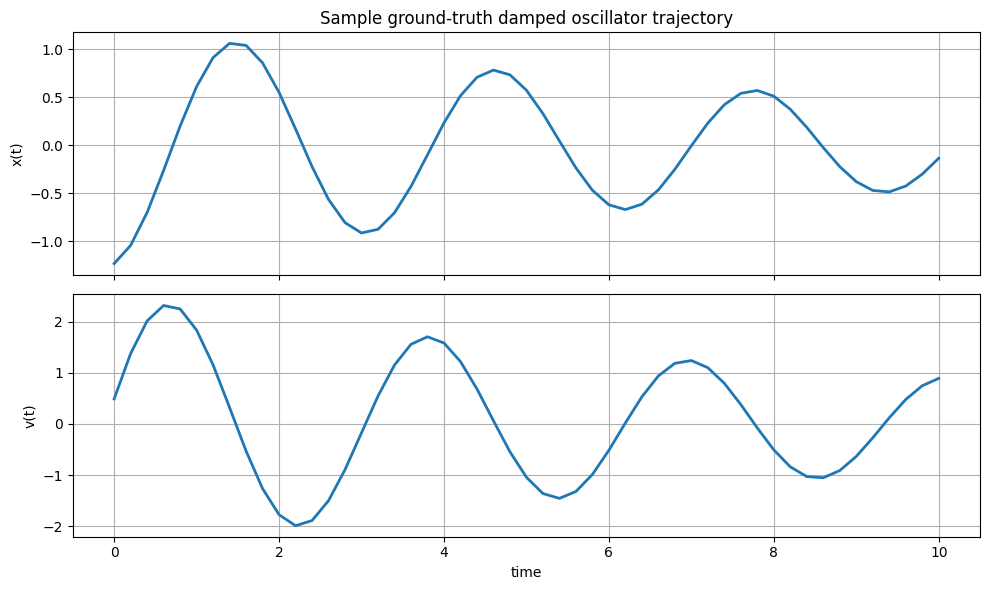

In [5]:

sample_idx = 0
sample_traj = trajectories[sample_idx]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(T_GRID, sample_traj[:, 0], linewidth=2)
axes[0].set_ylabel("x(t)")
axes[0].set_title("Sample ground-truth damped oscillator trajectory")

axes[1].plot(T_GRID, sample_traj[:, 1], linewidth=2)
axes[1].set_ylabel("v(t)")
axes[1].set_xlabel("time")

fig.tight_layout()
plt.show()



## 5. Models

The notebook compares three trajectory models.

### ResNet baseline
This is a discrete-depth baseline:
$$
x_{k+1} = x_k + h\,F_k(x_k).
$$


### Fixed-step Neural ODE
This uses a learned vector field
$$
\dot{z}(t) = f_\theta(t, z(t))
$$

and then integrates it numerically with either:
- Euler, or
- RK4.

So this is where the Neural ODE appears.


In [6]:

Tensor = torch.Tensor


class MLP(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, depth: int = 2):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers.append(nn.Linear(d, hidden_dim))
            layers.append(nn.Tanh())
            d = hidden_dim
        layers.append(nn.Linear(d, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x: Tensor) -> Tensor:
        return self.net(x)


class VectorField(nn.Module):
    def __init__(self, state_dim: int, hidden_dim: int, depth: int = 2, time_dependent: bool = True):
        super().__init__()
        self.time_dependent = time_dependent
        in_dim = state_dim + (1 if time_dependent else 0)
        self.net = MLP(in_dim, hidden_dim, state_dim, depth=depth)

    def forward(self, t: Tensor | float, x: Tensor) -> Tensor:
        if isinstance(t, float):
            t_tensor = torch.full((x.shape[0], 1), float(t), dtype=x.dtype, device=x.device)
        else:
            if t.ndim == 0:
                t_tensor = torch.full((x.shape[0], 1), float(t.item()), dtype=x.dtype, device=x.device)
            else:
                t_tensor = t.reshape(-1, 1).to(device=x.device, dtype=x.dtype)
        if self.time_dependent:
            inp = torch.cat([x, t_tensor], dim=1)
        else:
            inp = x
        return self.net(inp)


class ResidualBlock(nn.Module):
    def __init__(self, state_dim: int, hidden_dim: int, depth: int = 2):
        super().__init__()
        self.net = MLP(state_dim, hidden_dim, state_dim, depth=depth)

    def forward(self, x: Tensor) -> Tensor:
        return self.net(x)


class ResNetTrajectoryModel(nn.Module):
    def __init__(self, state_dim: int, hidden_dim: int, n_steps: int, dt: float, depth: int = 2):
        super().__init__()
        self.n_steps = n_steps
        self.dt = dt
        self.blocks = nn.ModuleList([ResidualBlock(state_dim, hidden_dim, depth=depth) for _ in range(n_steps)])

    def forward(self, x0: Tensor) -> Tensor:
        x = x0
        xs = [x0]
        for k in range(self.n_steps):
            x = x + self.dt * self.blocks[k](x)
            xs.append(x)
        return torch.stack(xs, dim=1)

    @property
    def nfe_per_forward(self) -> int:
        return self.n_steps


class FixedStepNODEModel(nn.Module):
    def __init__(
        self,
        state_dim: int,
        hidden_dim: int,
        t_grid: Sequence[float],
        solver: str = "euler",
        substeps: int = 1,
        depth: int = 2,
        time_dependent: bool = True,
    ):
        super().__init__()
        self.solver = solver.lower()
        self.substeps = int(substeps)
        self.t_grid = torch.tensor(list(t_grid), dtype=torch.float32)
        self.vector_field = VectorField(state_dim, hidden_dim, depth=depth, time_dependent=time_dependent)

    def _euler_step(self, t: float, x: Tensor, h: float) -> Tensor:
        return x + h * self.vector_field(t, x)

    def _rk4_step(self, t: float, x: Tensor, h: float) -> Tensor:
        k1 = self.vector_field(t, x)
        k2 = self.vector_field(t + 0.5 * h, x + 0.5 * h * k1)
        k3 = self.vector_field(t + 0.5 * h, x + 0.5 * h * k2)
        k4 = self.vector_field(t + h, x + h * k3)
        return x + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

    def forward(self, x0: Tensor) -> Tensor:
        t_grid = self.t_grid.to(device=x0.device, dtype=x0.dtype)
        x = x0
        xs = [x0]
        for i in range(len(t_grid) - 1):
            t0 = float(t_grid[i].item())
            dt = float((t_grid[i + 1] - t_grid[i]).item())
            h = dt / float(self.substeps)
            t = t0
            for _ in range(self.substeps):
                if self.solver == "euler":
                    x = self._euler_step(t, x, h)
                elif self.solver == "rk4":
                    x = self._rk4_step(t, x, h)
                else:
                    raise ValueError(f"Unknown solver: {self.solver}")
                t += h
            xs.append(x)
        return torch.stack(xs, dim=1)

    @property
    def nfe_per_forward(self) -> int:
        n_intervals = len(self.t_grid) - 1
        if self.solver == "euler":
            return n_intervals * self.substeps
        if self.solver == "rk4":
            return 4 * n_intervals * self.substeps
        return -1


def build_model(model_name: str, t_grid: np.ndarray) -> nn.Module:
    dt = float(t_grid[1] - t_grid[0])
    n_steps = len(t_grid) - 1
    if model_name == "resnet":
        return ResNetTrajectoryModel(state_dim=2, hidden_dim=HIDDEN_DIM, n_steps=n_steps, dt=dt, depth=MLP_DEPTH)
    if model_name == "node_euler":
        return FixedStepNODEModel(state_dim=2, hidden_dim=HIDDEN_DIM, t_grid=t_grid, solver="euler", substeps=NODE_SUBSTEPS, depth=MLP_DEPTH)
    if model_name == "node_rk4":
        return FixedStepNODEModel(state_dim=2, hidden_dim=HIDDEN_DIM, t_grid=t_grid, solver="rk4", substeps=NODE_SUBSTEPS, depth=MLP_DEPTH)
    raise ValueError(f"Unknown model: {model_name}")


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)



## 6. Training and evaluation utilities


In [7]:

def trajectory_mse(pred: Tensor, target: Tensor) -> Tensor:
    return torch.mean((pred - target) ** 2)


def relative_trajectory_l2(pred: Tensor, target: Tensor) -> Tensor:
    diff = torch.linalg.norm(pred - target, dim=(1, 2))
    ref = torch.linalg.norm(target, dim=(1, 2)).clamp_min(1e-12)
    return torch.mean(diff / ref)


def plot_history(history_df: pd.DataFrame, model_name: str, out_dir: Path) -> None:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(history_df["epoch"], history_df["train_loss"], label="train")
    ax.plot(history_df["epoch"], history_df["val_loss"], label="validation")
    ax.set_yscale("log")
    ax.set_xlabel("epoch")
    ax.set_ylabel("trajectory MSE")
    ax.set_title(f"Training history: {model_name}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_dir / f"{model_name}_loss_history.png", dpi=180)
    plt.show()


def train_one_model(model_name: str, train_data: TrajectoryDataset, val_data: TrajectoryDataset, t_grid: np.ndarray):
    model = build_model(model_name, t_grid).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

    history = []
    best_val = math.inf
    best_state = None
    bad_epochs = 0
    train_start = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss_sum = 0.0
        train_rel_sum = 0.0
        n_train = 0

        for x0, y in train_loader:
            x0 = x0.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            pred = model(x0)
            loss = trajectory_mse(pred, y)
            rel = relative_trajectory_l2(pred, y)
            loss.backward()
            optimizer.step()

            batch_size = x0.shape[0]
            train_loss_sum += float(loss.item()) * batch_size
            train_rel_sum += float(rel.item()) * batch_size
            n_train += batch_size

        model.eval()
        val_loss_sum = 0.0
        val_rel_sum = 0.0
        n_val = 0
        with torch.no_grad():
            for x0, y in val_loader:
                x0 = x0.to(device)
                y = y.to(device)
                pred = model(x0)
                loss = trajectory_mse(pred, y)
                rel = relative_trajectory_l2(pred, y)
                batch_size = x0.shape[0]
                val_loss_sum += float(loss.item()) * batch_size
                val_rel_sum += float(rel.item()) * batch_size
                n_val += batch_size

        train_loss = train_loss_sum / max(1, n_train)
        train_rel = train_rel_sum / max(1, n_train)
        val_loss = val_loss_sum / max(1, n_val)
        val_rel = val_rel_sum / max(1, n_val)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_rel_l2": train_rel,
            "val_loss": val_loss,
            "val_rel_l2": val_rel,
        })

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= EARLY_STOPPING_PATIENCE:
                break

    train_time = time.perf_counter() - train_start

    if best_state is None:
        raise RuntimeError("Training failed to produce a valid model state.")

    model.load_state_dict(best_state)

    model_dir = OUT_DIR / model_name
    model_dir.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), model_dir / f"{model_name}_best.pt")

    history_df = pd.DataFrame(history)
    history_df.to_csv(model_dir / f"{model_name}_history.csv", index=False)

    summary = {
        "model": model_name,
        "n_parameters": count_parameters(model),
        "best_val_loss": best_val,
        "epochs_ran": int(len(history_df)),
        "train_time_sec": train_time,
        "nfe_per_forward": int(getattr(model, "nfe_per_forward", -1)),
    }

    with open(model_dir / f"{model_name}_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    return model, history_df, summary


def evaluate_model(model: nn.Module, test_data: TrajectoryDataset, model_name: str):
    loader = DataLoader(test_data, batch_size=256, shuffle=False)
    model.eval()

    mse_sum = 0.0
    rel_sum = 0.0
    n_total = 0
    all_x0 = []
    all_true = []
    all_pred = []

    infer_start = time.perf_counter()
    with torch.no_grad():
        for x0, y in loader:
            x0 = x0.to(device)
            y = y.to(device)
            pred = model(x0)
            mse = trajectory_mse(pred, y)
            rel = relative_trajectory_l2(pred, y)
            batch_size = x0.shape[0]
            mse_sum += float(mse.item()) * batch_size
            rel_sum += float(rel.item()) * batch_size
            n_total += batch_size
            all_x0.append(x0.cpu().numpy())
            all_true.append(y.cpu().numpy())
            all_pred.append(pred.cpu().numpy())
    infer_time = time.perf_counter() - infer_start

    x0_np = np.concatenate(all_x0, axis=0)
    true_np = np.concatenate(all_true, axis=0)
    pred_np = np.concatenate(all_pred, axis=0)

    model_dir = OUT_DIR / model_name
    np.savez(model_dir / f"{model_name}_test_predictions.npz", x0=x0_np, y_true=true_np, y_pred=pred_np)

    metrics = {
        "test_mse": mse_sum / max(1, n_total),
        "test_rel_l2": rel_sum / max(1, n_total),
        "inference_time_sec": infer_time,
    }
    return metrics, x0_np, true_np, pred_np



## 7. Train all models

This is the main experiment cell.


In [8]:

results = []
histories = {}
predictions = {}
y_true = None

for model_name in MODEL_NAMES:
    print(f"\nTraining {model_name} ...")
    model, history_df, summary = train_one_model(model_name, train_data, val_data, T_GRID)
    histories[model_name] = history_df
    metrics, _, true_np, pred_np = evaluate_model(model, test_data, model_name)
    predictions[model_name] = pred_np
    if y_true is None:
        y_true = true_np
    row = {**summary, **metrics}
    results.append(row)
    print(row)

results_df = pd.DataFrame(results).sort_values("test_mse").reset_index(drop=True)
results_df.to_csv(OUT_DIR / "model_comparison.csv", index=False)
results_df



Training resnet ...
{'model': 'resnet', 'n_parameters': 224100, 'best_val_loss': 0.13130564242601395, 'epochs_ran': 150, 'train_time_sec': 9.66494608297944, 'nfe_per_forward': 50, 'test_mse': 0.1546710580587387, 'test_rel_l2': 0.4490399658679962, 'inference_time_sec': 0.0035202079452574253}

Training node_euler ...
{'model': 'node_euler', 'n_parameters': 4546, 'best_val_loss': 0.005943206371739507, 'epochs_ran': 150, 'train_time_sec': 6.485328584036324, 'nfe_per_forward': 50, 'test_mse': 0.006656459532678127, 'test_rel_l2': 0.09852562099695206, 'inference_time_sec': 0.0036845419672317803}

Training node_rk4 ...
{'model': 'node_rk4', 'n_parameters': 4546, 'best_val_loss': 0.0061601756606251, 'epochs_ran': 150, 'train_time_sec': 25.741120416962076, 'nfe_per_forward': 200, 'test_mse': 0.006881814915686846, 'test_rel_l2': 0.09496119618415833, 'inference_time_sec': 0.014537792012561113}


,model,n_parameters,best_val_loss,epochs_ran,train_time_sec,nfe_per_forward,test_mse,test_rel_l2,inference_time_sec
0,node_euler,4546,0.005943,150,6.485329,50,0.006656,0.098526,0.003685
1,node_rk4,4546,0.006160,150,25.741120,200,0.006882,0.094961,0.014538
2,resnet,224100,0.131306,150,9.664946,50,0.154671,0.449040,0.003520



## 8. Compare training histories


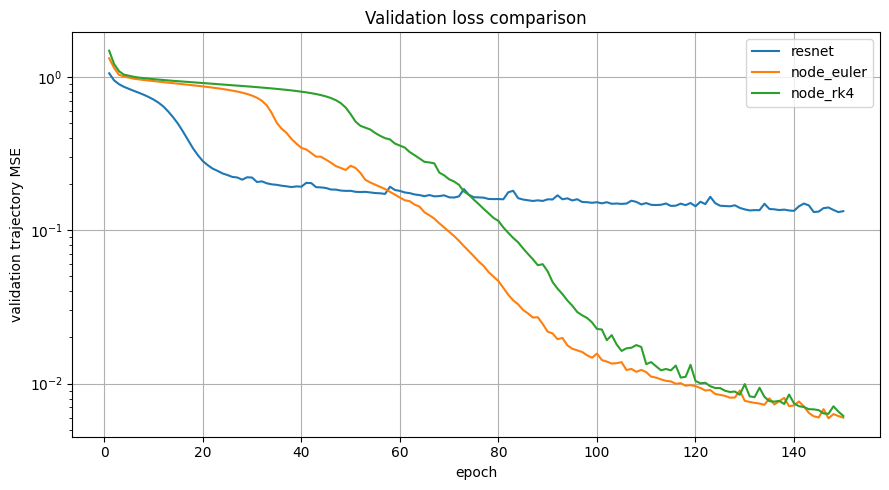

In [9]:

fig, ax = plt.subplots(figsize=(9, 5))
for model_name, history_df in histories.items():
    ax.plot(history_df["epoch"], history_df["val_loss"], label=model_name)
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("validation trajectory MSE")
ax.set_title("Validation loss comparison")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "validation_loss_comparison.png", dpi=180)
plt.show()



## 9. Plot one test trajectory


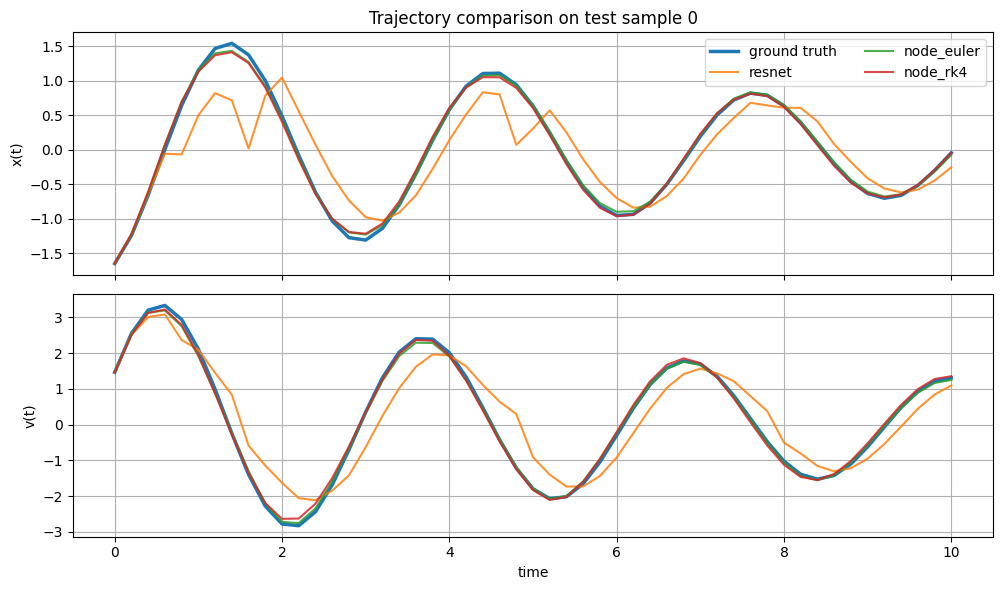

In [10]:

def plot_sample_trajectory(sample_idx: int = 0):
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    axes[0].plot(T_GRID, y_true[sample_idx, :, 0], label="ground truth", linewidth=2.5)
    axes[1].plot(T_GRID, y_true[sample_idx, :, 1], label="ground truth", linewidth=2.5)

    for model_name, pred in predictions.items():
        axes[0].plot(T_GRID, pred[sample_idx, :, 0], label=model_name, alpha=0.85)
        axes[1].plot(T_GRID, pred[sample_idx, :, 1], label=model_name, alpha=0.85)

    axes[0].set_ylabel("x(t)")
    axes[1].set_ylabel("v(t)")
    axes[1].set_xlabel("time")
    axes[0].legend(ncol=2)
    axes[0].set_title(f"Trajectory comparison on test sample {sample_idx}")
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"sample_{sample_idx}_trajectory_comparison.png", dpi=180)
    plt.show()


plot_sample_trajectory(sample_idx=0)



## 10. Phase portrait comparison

For the damped oscillator, a good learned model should reproduce the inward spiral behavior in phase space.


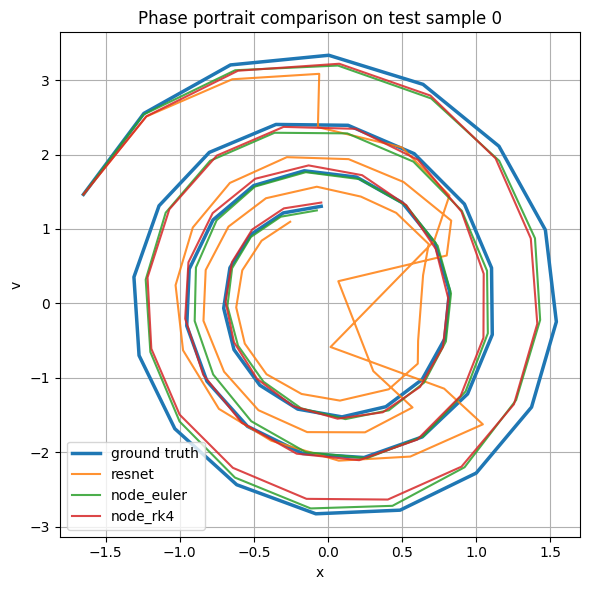

In [11]:

def plot_phase_portrait(sample_idx: int = 0):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(y_true[sample_idx, :, 0], y_true[sample_idx, :, 1], label="ground truth", linewidth=2.5)
    for model_name, pred in predictions.items():
        ax.plot(pred[sample_idx, :, 0], pred[sample_idx, :, 1], label=model_name, alpha=0.85)
    ax.set_xlabel("x")
    ax.set_ylabel("v")
    ax.set_title(f"Phase portrait comparison on test sample {sample_idx}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"sample_{sample_idx}_phase_portrait.png", dpi=180)
    plt.show()


plot_phase_portrait(sample_idx=0)



## 11. Parameter count vs test error

This is a simple thesis-friendly summary plot.


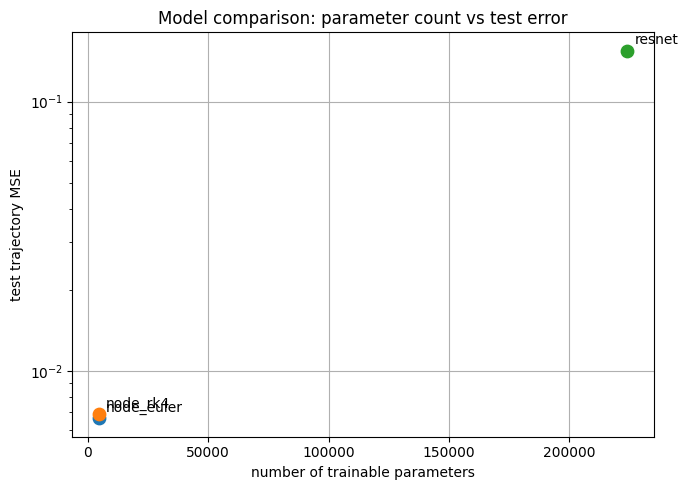

In [12]:

fig, ax = plt.subplots(figsize=(7, 5))
for _, row in results_df.iterrows():
    ax.scatter(row["n_parameters"], row["test_mse"], s=80)
    ax.annotate(row["model"], (row["n_parameters"], row["test_mse"]), xytext=(5, 5), textcoords="offset points")
ax.set_yscale("log")
ax.set_xlabel("number of trainable parameters")
ax.set_ylabel("test trajectory MSE")
ax.set_title("Model comparison: parameter count vs test error")
fig.tight_layout()
fig.savefig(OUT_DIR / "parameter_count_vs_test_mse.png", dpi=180)
plt.show()



## 12. Save a compact experiment summary


In [13]:

summary = {
    "best_model_by_test_mse": results_df.iloc[0]["model"],
    "results_table": results_df.to_dict(orient="records"),
}
with open(OUT_DIR / "experiment_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(results_df)


        model  n_parameters  best_val_loss  epochs_ran  train_time_sec  \
0  node_euler          4546       0.005943         150        6.485329   
1    node_rk4          4546       0.006160         150       25.741120   
2      resnet        224100       0.131306         150        9.664946   

   nfe_per_forward  test_mse  test_rel_l2  inference_time_sec  
0               50  0.006656     0.098526            0.003685  
1              200  0.006882     0.094961            0.014538  
2               50  0.154671     0.449040            0.003520  
